# MedBridge — Data Extraction & Exploratory Data Analysis

**Purpose.** This notebook extracts and explores the dataset powering MedBridge's demand
forecasting. The dataset originates from the **Samir** branch's ledger-based simulation
pipeline (`training/generate_ledger_data.py`) and is reproduced here deterministically so
anyone can regenerate it from scratch.

**What you'll learn.**
1. How the raw dataset is produced (event-driven weekly inventory simulation).
2. The schema of each table (`hospitals`, `medicines`, `transactions`, `inventory_state`, `inventory`).
3. Demand behaviour across geography, medicine category, and season — the signals the model must learn.

> Run everything from `apps/ml-service/` (the notebook's working directory is the repo's ML folder).

In [1]:
import sys, warnings
from pathlib import Path

def _find_root() -> Path:
    """Locate the apps/ml-service root regardless of the kernel's cwd
    (works both when launched from apps/ml-service and from notebooks/)."""
    cwd = Path.cwd()
    for start in (cwd, cwd.parent, cwd.parent.parent):
        if (start / "training" / "generate_ledger_data.py").exists():
            return start
    d = cwd
    for _ in range(6):
        if (d / "training" / "generate_ledger_data.py").exists():
            return d
        d = d.parent
    return cwd

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 5)})
sns.set_theme(style="whitegrid", context="notebook")

# MedBridge palette (shared with the FastAPI service + frontend)
NAVY, TEAL, AMBER, CORAL, GREY, LIGHT = "#233A5C", "#0E8C82", "#E8A23D", "#D96C5F", "#8A94A3", "#E4E9EE"

RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
ART = ROOT / "artifacts"
REPORTS = ROOT / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

## 1. Reproducible dataset extraction

The dataset is **generated**, not downloaded. Two scripts are the source of truth:

- `training/generate_synthetic_data.py` — builds the 41-hospital / 72-medicine reference tables
  (Nepal-context: 7 provinces, facility types, specialty mix, ABC inventory classes, cold-chain flags).
- `training/generate_ledger_data.py` — runs a **batch-level, policy-driven weekly simulation**
  (~183 weeks) that emits every stock-changing event (consumption, procurement with road-access
  lead times, expiry write-offs, cold-chain spoilage, exchanges, emergencies) and derives
  `transactions.csv`, `inventory_state.csv`, `inventory.csv`, `inventory_snapshots.csv`, and
  `pending_arrivals.json`.

The cell below generates the data only if it isn't already present (it takes ~2 minutes).

In [2]:
# Generate the dataset if missing (idempotent — skips when files already exist)
needed = ["hospitals.csv", "medicines.csv", "transactions.csv",
          "inventory_state.csv", "inventory.csv", "inventory_snapshots.csv"]
if all((RAW / f).exists() for f in needed):
    print("Dataset already present — skipping generation.")
else:
    print("Generating dataset (this simulates ~183 weeks of ledger events)...")
    from training.generate_ledger_data import main as gen_main
    gen_main()
    print("Done.")

Dataset already present — skipping generation.


In [3]:
# Load every raw table
hospitals = pd.read_csv(RAW / "hospitals.csv")
medicines = pd.read_csv(RAW / "medicines.csv")
inventory_state = pd.read_csv(RAW / "inventory_state.csv", parse_dates=["week_start"])
inventory = pd.read_csv(RAW / "inventory.csv")
snapshots = pd.read_csv(RAW / "inventory_snapshots.csv")

# The full event ledger is ~1.1M rows; read only the columns we need
transactions = pd.read_csv(
    RAW / "transactions.csv",
    usecols=["hospital_id", "medicine_id", "date", "type", "quantity"],
    dtype={"hospital_id": "category", "medicine_id": "category", "type": "category"},
)

for name, df in [("hospitals", hospitals), ("medicines", medicines),
                 ("transactions", transactions), ("inventory_state", inventory_state),
                 ("inventory", inventory), ("snapshots", snapshots)]:
    print(f"{name:>16}: {df.shape[0]:>10,} rows x {df.shape[1]:>3} cols")

       hospitals:         41 rows x  20 cols
       medicines:         72 rows x  14 cols
    transactions:  1,083,154 rows x   5 cols
 inventory_state:    540,216 rows x   9 cols
       inventory:      3,801 rows x   7 cols
       snapshots:      3,801 rows x  14 cols


## 2. Reference tables — hospitals & medicines

In [4]:
print("Hospitals:", hospitals.shape)
hospitals.head(6)

Hospitals: (41, 20)


,hospital_id,hospital_name,facility_type,province,district,municipality,ecoregion,urban_class,latitude,longitude,bed_capacity,ownership,is_demo,specialty_focus,load_factor,urban_factor,is_referral,road_access_score,demo_username,demo_role
0,HOSP-BG-001,Bir Hospital,Central_Hospital,Bagmati,Kathmandu,Kathmandu,Hill,Metropolitan,27.7052,85.3140,460,public,1,General / Emergency / Referral,1.00,1.15,1,0.762,hosp_bg_001,hospital_admin
1,HOSP-BG-002,Tribhuvan University Teaching Hospital (TUTH),Teaching_Hospital,Bagmati,Kathmandu,Maharajgunj,Hill,Metropolitan,27.7360,85.3300,700,public,1,Teaching / Multi-specialty,0.85,1.15,1,0.708,hosp_bg_002,hospital_admin
2,HOSP-BG-003,Bhaktapur Cancer Hospital,Cancer_Hospital,Bagmati,Bhaktapur,Dudhpati,Hill,Municipality,27.6725,85.4278,120,public,1,Oncology / Chemotherapy / Palliative,0.70,0.75,1,0.780,hosp_bg_003,hospital_admin
3,HOSP-BG-004,Kanti Children's Hospital,Children_Hospital,Bagmati,Kathmandu,Maharajgunj,Hill,Metropolitan,27.7375,85.3320,350,public,1,Pediatrics / Neonatal / Vaccines,0.55,1.15,1,0.788,hosp_bg_004,hospital_admin
4,HOSP-BG-005,Paropakar Maternity & Women's Hospital,Maternity_Hospital,Bagmati,Kathmandu,Thapathali,Hill,Metropolitan,27.6900,85.3200,415,public,1,OBGYN / Labor / Blood bank,0.50,1.15,1,0.672,hosp_bg_005,hospital_admin
5,HOSP-KP-002,Koshi Hospital,Regional_Hospital,Koshi,Morang,Biratnagar,Terai,Metropolitan,26.4525,87.2718,350,public,1,Regional general / Monsoon load,0.65,1.15,1,0.898,hosp_kp_002,hospital_admin


In [5]:
print("Medicines:", medicines.shape)
medicines.head(6)

Medicines: (72, 14)


,medicine_id,generic_name,brand_example,category,dosage_form,strength,unit,pack_size,shelf_life_months,unit_cost_npr,requires_cold_chain,is_essential,base_demand_per_100_beds,abc_class
0,MED-001,Paracetamol,Calpol / Napa,Antipyretic,Tablet,500mg,tablet,100,36,1.5,0,1,45.0,B
1,MED-002,Paracetamol,PCM Syrup,Antipyretic,Syrup,125mg/5ml,bottle,1,24,45.0,0,1,8.0,A
2,MED-003,Ibuprofen,Brufen,Analgesic,Tablet,400mg,tablet,100,36,2.5,0,1,18.0,B
3,MED-004,Diclofenac,Voveran,Analgesic,Injection,75mg/3ml,ampoule,10,24,25.0,0,1,6.0,B
4,MED-005,Amoxicillin,Amoxil,Antibiotic,Capsule,500mg,capsule,100,24,6.0,0,1,22.0,B
5,MED-006,Amoxicillin + Clavulanate,Augmentin,Antibiotic,Tablet,625mg,tablet,10,24,35.0,0,1,10.0,A


### Hospitals across provinces

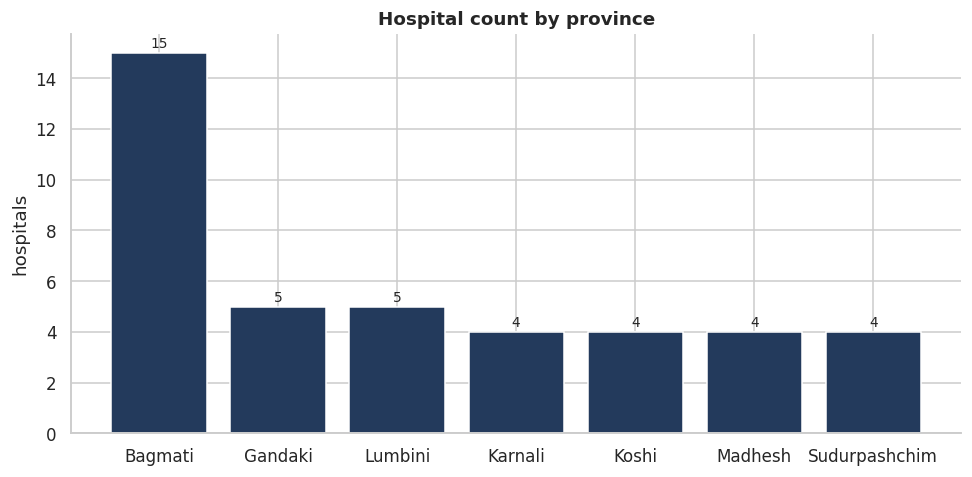

In [6]:
prov = hospitals.groupby("province", as_index=False).agg(
    hospitals=("hospital_id", "nunique"),
    beds=("bed_capacity", "sum"),
).sort_values("hospitals", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(prov["province"], prov["hospitals"], color=NAVY)
ax.set_title("Hospital count by province", fontweight="bold")
ax.set_ylabel("hospitals")
for b, v in zip(bars, prov["hospitals"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.2, str(v), ha="center", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

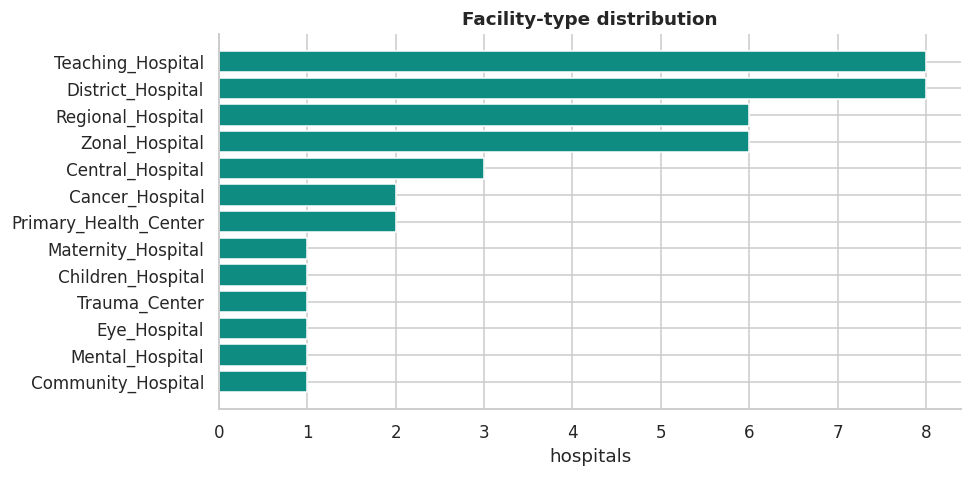

In [7]:
ftype = hospitals["facility_type"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ftype.index[::-1], ftype.values[::-1], color=TEAL)
ax.set_title("Facility-type distribution", fontweight="bold")
ax.set_xlabel("hospitals")
sns.despine()
plt.tight_layout()
plt.show()

### Medicine catalogue

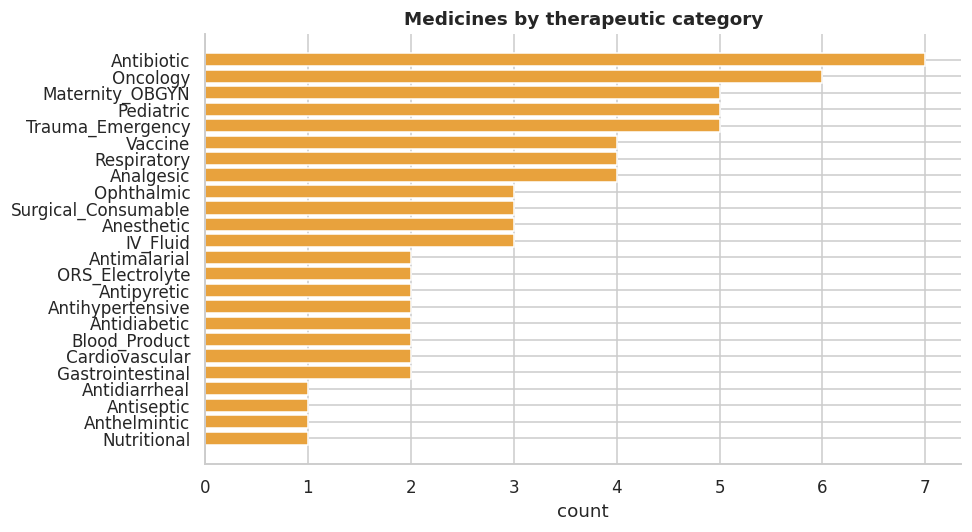

In [8]:
cats = medicines["category"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cats.index[::-1], cats.values[::-1], color=AMBER)
ax.set_title("Medicines by therapeutic category", fontweight="bold")
ax.set_xlabel("count")
sns.despine()
plt.tight_layout()
plt.show()

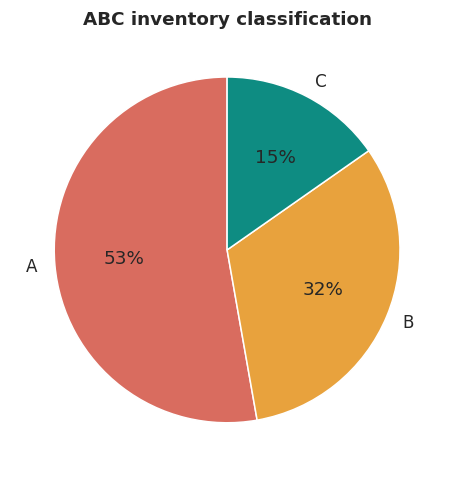

In [9]:
abc = medicines["abc_class"].value_counts().reindex(["A", "B", "C"])
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.pie(abc, labels=abc.index, autopct="%1.0f%%", startangle=90,
       colors=[CORAL, AMBER, TEAL], wedgeprops={"edgecolor": "white"})
ax.set_title("ABC inventory classification", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Demand behaviour

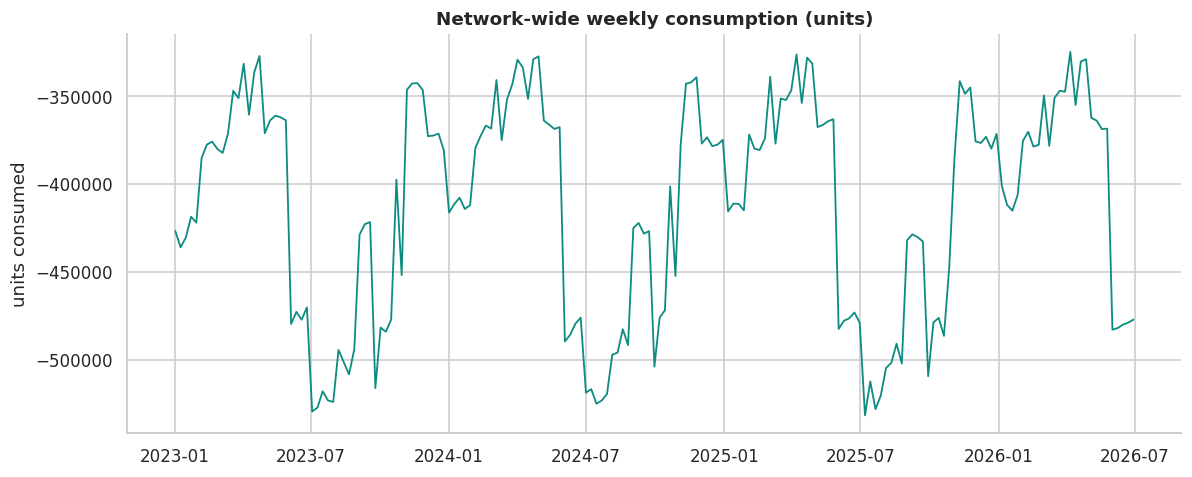

In [10]:
# Total weekly consumption across the whole network
weekly = transactions[transactions["type"] == "CONSUMPTION"].copy()
weekly["date"] = pd.to_datetime(weekly["date"])
weekly_total = weekly.groupby("date", as_index=False)["quantity"].sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(weekly_total["date"], weekly_total["quantity"], color=TEAL, lw=1.2)
ax.set_title("Network-wide weekly consumption (units)", fontweight="bold")
ax.set_ylabel("units consumed")
ax.set_xlabel("")
sns.despine()
plt.tight_layout()
plt.show()

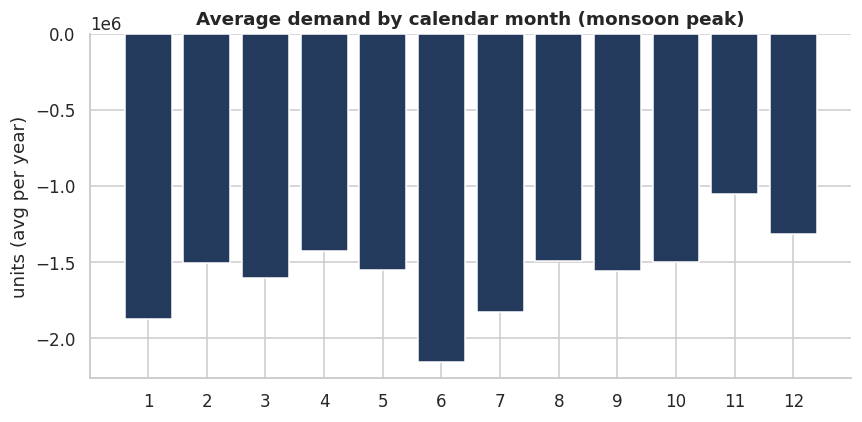

In [11]:
# Seasonality: average demand by calendar month
weekly["month"] = weekly["date"].dt.month
monthly = weekly.groupby("month")["quantity"].sum() / weekly["date"].dt.year.nunique()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly.index, monthly.values, color=NAVY)
ax.set_xticks(range(1, 13))
ax.set_title("Average demand by calendar month (monsoon peak)", fontweight="bold")
ax.set_ylabel("units (avg per year)")
sns.despine()
plt.tight_layout()
plt.show()

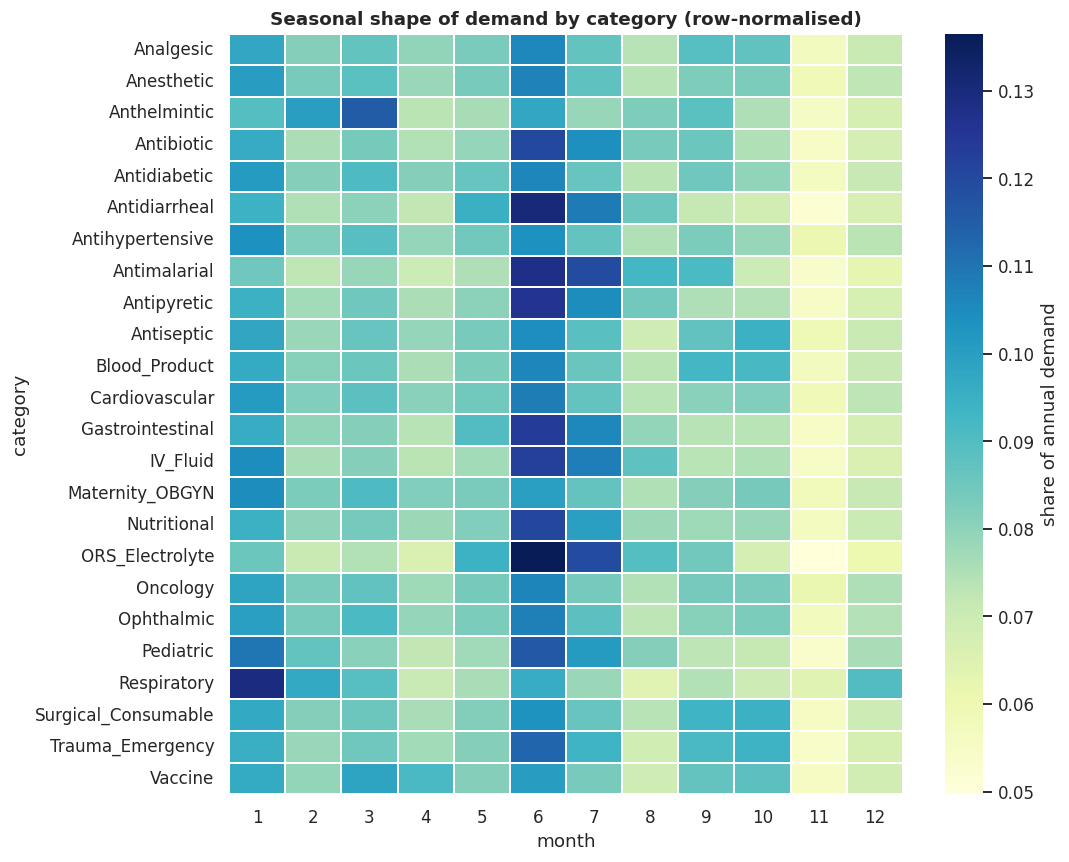

In [12]:
# Category x month heatmap — which categories peak when
pivot = weekly.merge(medicines[["medicine_id", "category"]], on="medicine_id")
pivot["month"] = pivot["date"].dt.month
hm = pivot.pivot_table(index="category", columns="month", values="quantity", aggfunc="sum")
# normalise each row so seasonal shape (not absolute size) is visible
hm = hm.div(hm.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(hm, cmap="YlGnBu", ax=ax, linewidths=0.3, cbar_kws={"label": "share of annual demand"})
ax.set_title("Seasonal shape of demand by category (row-normalised)", fontweight="bold")
plt.tight_layout()
plt.show()

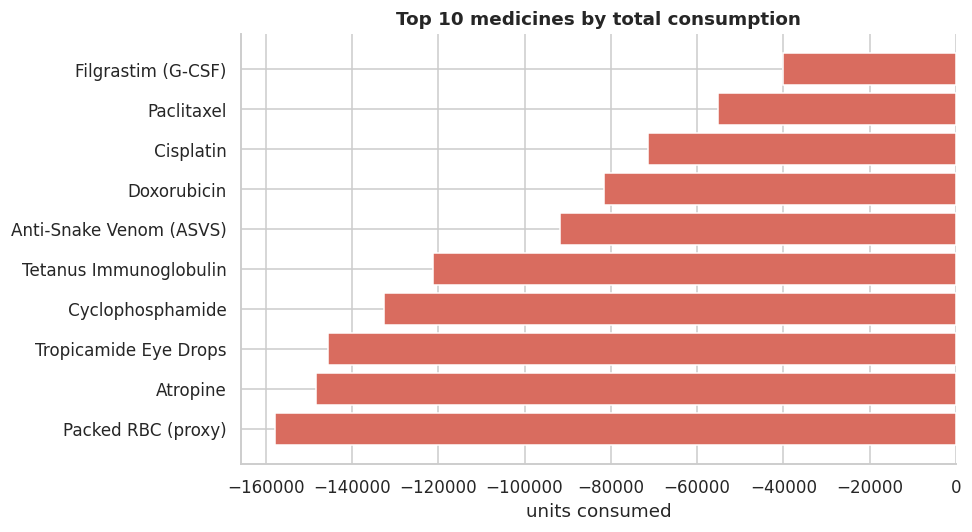

In [13]:
# Top 10 medicines by total consumption
top = weekly.merge(medicines[["medicine_id", "generic_name"]], on="medicine_id")
top10 = top.groupby("generic_name")["quantity"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10.index[::-1], top10.values[::-1], color=CORAL)
ax.set_title("Top 10 medicines by total consumption", fontweight="bold")
ax.set_xlabel("units consumed")
sns.despine()
plt.tight_layout()
plt.show()

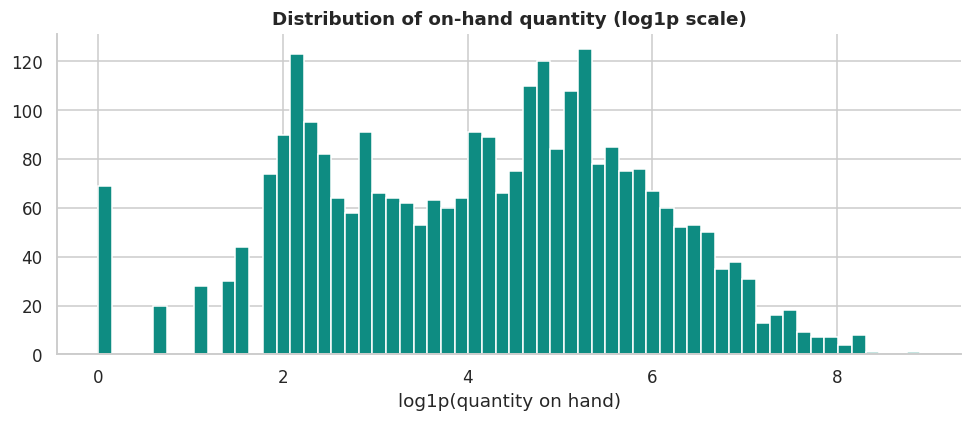

In [14]:
# Demand is heavy-tailed: a few (hospital, medicine) pairs dominate
state_latest = inventory_state.groupby(["hospital_id", "medicine_id"], as_index=False)["quantity_on_hand"].last()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log1p(state_latest["quantity_on_hand"]), bins=60, color=TEAL)
ax.set_title("Distribution of on-hand quantity (log1p scale)", fontweight="bold")
ax.set_xlabel("log1p(quantity on hand)")
sns.despine()
plt.tight_layout()
plt.show()

In [15]:
# Stock-status mix at the last simulated week
status = inventory_state[inventory_state["week_start"] == inventory_state["week_start"].max()]
print(status["stock_status"].value_counts(normalize=True).round(3) * 100)

stock_status
OK              68.7
LOW_STOCK       29.0
OUT_OF_STOCK     2.3
Name: proportion, dtype: float64


## 4. Key takeaways

- **41 hospitals × 72 medicines** simulated weekly for **~183 weeks** → 540k `inventory_state` rows and
  ~1.08M ledger events, then rolled up into **504,792 supervised feature rows** (`data/processed/demand_features.csv`).
- Demand is **heavy-tailed** (a few pairs dominate) and **strongly seasonal** (monsoon peaks for antibiotics,
  antipyretics and ORS; winter peaks for respiratory items) — a linear model will struggle with these non-linearities.
- 8 **demo hospitals** (`is_demo=1`) are used for the multi-login showcase; the rest provide cross-sectional
  diversity (Terai → Mountain, PHC → teaching hospital) that lets the model generalise.